In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import date2num
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

/opt/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [3]:
# Load data
df = pd.read_csv('historical_stablecoin.csv')
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,peggedUSD,peggedEUR,peggedVAR,peggedJPY,peggedCNY,peggedUAH,peggedARS,peggedGBP,peggedCAD,peggedCHF,peggedAUD,peggedREAL
0,2021-01-01,28286859559,3871222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,28825490421,4272046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,28995680791,5510939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,29328599685,5971796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,29771217419,7836686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Detect first non null date for each column
first_dates = {}
for col in df.columns[1:]:  # Skip Date column
    non_null = df[col].notna()
    if non_null.any():
        idx = non_null.idxmax()
        first_dates[col] = df.loc[idx, 'date']
    else:
        first_dates[col] = pd.NaT

launch_df = pd.DataFrame([{'currency': k, 'launch_date': v} for k, v in first_dates.items()])
launch_df = launch_df.sort_values('launch_date').reset_index(drop=True)

print("Launch Dates of Stablecoins:")
print(launch_df)

Launch Dates of Stablecoins:
      currency launch_date
0    peggedUSD  2021-01-01
1    peggedEUR  2021-01-01
2    peggedVAR  2021-02-14
3    peggedJPY  2023-08-10
4    peggedCNY  2023-09-01
5    peggedUAH  2023-10-04
6    peggedARS  2023-10-06
7    peggedGBP  2023-11-23
8    peggedCAD  2023-12-08
9    peggedCHF  2024-01-25
10   peggedAUD  2024-03-06
11  peggedREAL  2024-07-03


# EDA

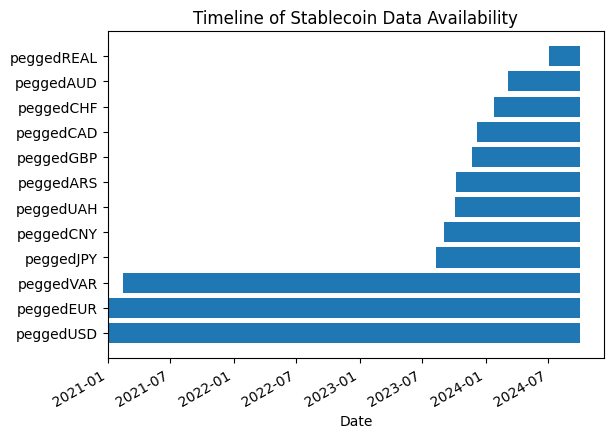

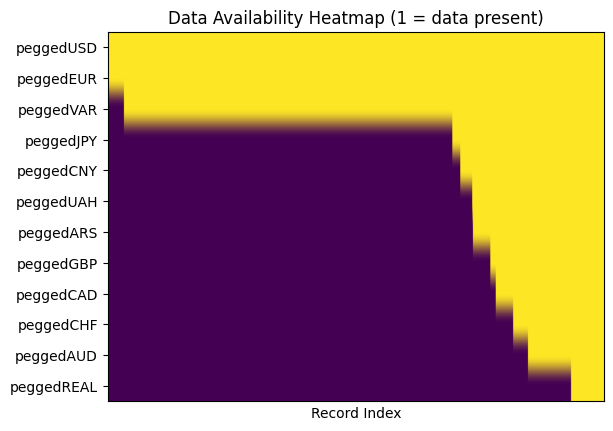

In [5]:
# Plot horizontal timeline of launches
last_date = df['date'].max()
starts = date2num(launch_df['launch_date'])
widths = date2num(last_date) - starts

plt.figure()
plt.barh(launch_df['currency'], widths, left=starts)
plt.xlabel('Date')
plt.title('Timeline of Stablecoin Data Availability')
plt.gca().xaxis_date()
plt.gcf().autofmt_xdate()
plt.show()

# Plot heatmap of data availability
availability = df.set_index('date')[launch_df['currency']].notna().T.astype(int)

plt.figure()
plt.imshow(availability, aspect='auto')
plt.yticks(range(len(availability.index)), availability.index)
plt.xticks([], [])
plt.xlabel('Record Index')
plt.title('Data Availability Heatmap (1 = data present)')
plt.show()

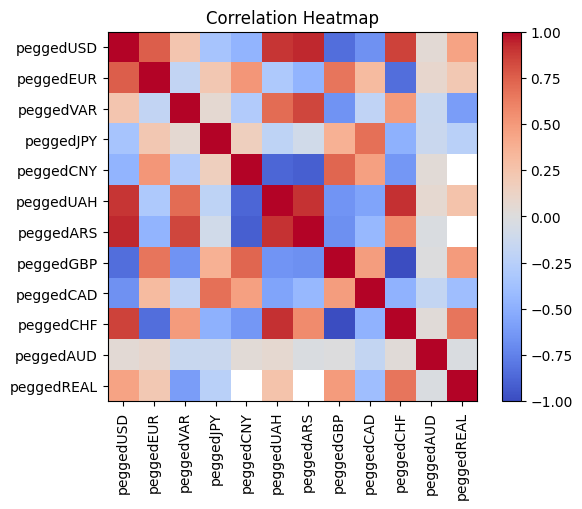

In [6]:
# Correlation Heatmap 
plt.figure()
corr = df.drop(columns='date').corr()
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.index)
plt.title('Correlation Heatmap')
plt.show()

# Deteksi Anomali

In [ ]:
# Get a list of all stablecoin columns
coins = df.columns.drop('date')

# Create monthly data for analysis
monthly = df.set_index('date')['peggedUSD'].resample('M').last().dropna()
monthly_all = df.set_index('date')[coins].resample('M').last().dropna(how='all')

# Create daily differences for spike detection
df_diff = df.set_index('date').diff()

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_62763/3277076228.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('date')['peggedUSD'].resample('M').last().dropna()
/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_62763/3277076228.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_all = df.set_index('date')[coins].resample('M').last().dropna(how='all')


In [28]:
# Anomali supply (Z-score > 3)
z_supply     = (monthly - monthly.mean()) / monthly.std()
supply_anoms = monthly[abs(z_supply) > 3]

# Anomali growth rate (Z-score > 3)
growth       = monthly.pct_change().dropna() * 100
z_growth     = (growth - growth.mean()) / growth.std()
growth_anoms = growth[abs(z_growth) > 3]

# Print
print("=== Supply Anomalies (Z>3) ===")
print(supply_anoms.to_string())

print("\n=== Growth Anomalies (Z>3) ===")
print(growth_anoms.to_string())

=== Supply Anomalies (Z>3) ===
date
2021-01-31    37189036128
Freq: ME

=== Growth Anomalies (Z>3) ===
date
2021-02-28    38.646913
2021-04-30    35.157105


## try new

In [47]:
from matplotlib.ticker import FuncFormatter

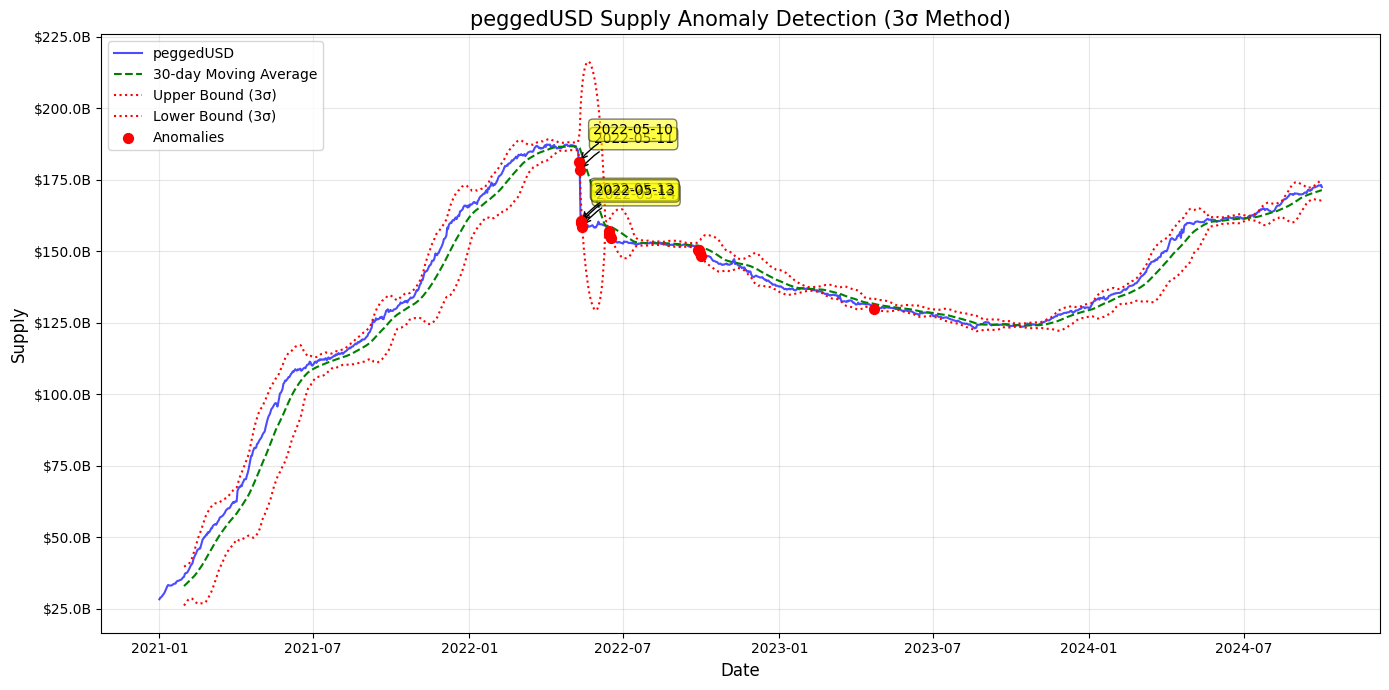

In [48]:
# 1. Enhanced Anomaly Detection Visualization for peggedUSD
plt.figure(figsize=(14, 7))

# Calculate rolling mean and standard deviation
window = 30
rolling_mean = df_indexed['peggedUSD'].rolling(window=window).mean()
rolling_std = df_indexed['peggedUSD'].rolling(window=window).std()

# Calculate upper and lower bounds (3 standard deviations)
upper_bound = rolling_mean + (rolling_std * 3)
lower_bound = rolling_mean - (rolling_std * 3)

# Identify anomalies - now everything has the same index
anomalies = df_indexed[((df_indexed['peggedUSD'] > upper_bound) | 
                      (df_indexed['peggedUSD'] < lower_bound)) &
                      (df_indexed['peggedUSD'].notnull())]

# Plot the data
plt.plot(df_indexed.index, df_indexed['peggedUSD'], label='peggedUSD', color='blue', alpha=0.7)
plt.plot(rolling_mean.index, rolling_mean, label=f'{window}-day Moving Average', color='green', linestyle='--')
plt.plot(upper_bound.index, upper_bound, label='Upper Bound (3σ)', color='red', linestyle=':')
plt.plot(lower_bound.index, lower_bound, label='Lower Bound (3σ)', color='red', linestyle=':')
plt.scatter(anomalies.index, anomalies['peggedUSD'], color='red', label='Anomalies', s=50, zorder=5)

# Mark and annotate the top 5 most significant anomalies
if len(anomalies) > 0:
    # Calculate how far each anomaly is from the rolling mean
    anomalies_mean_idx = anomalies.index.intersection(rolling_mean.index)
    if len(anomalies_mean_idx) > 0:
        distance = abs(anomalies.loc[anomalies_mean_idx, 'peggedUSD'] - 
                    rolling_mean.loc[anomalies_mean_idx])
        
        # Get top 5 anomalies (or fewer if there are less than 5)
        num_annotations = min(5, len(distance))
        top_idx = distance.nlargest(num_annotations).index
        
        for idx in top_idx:
            plt.annotate(f"{idx.strftime('%Y-%m-%d')}", 
                        xy=(idx, anomalies.loc[idx, 'peggedUSD']),
                        xytext=(10, 20),
                        textcoords='offset points',
                        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='black'),
                        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))

plt.title('peggedUSD Supply Anomaly Detection (3σ Method)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Supply', fontsize=12)

# Format the y-axis to show billions
def billions(x, pos):
    return f'${x/1e9:.1f}B'
plt.gca().yaxis.set_major_formatter(FuncFormatter(billions))

plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('usd_anomalies.png', dpi=300)
plt.show()


In [50]:
import seaborn as sns

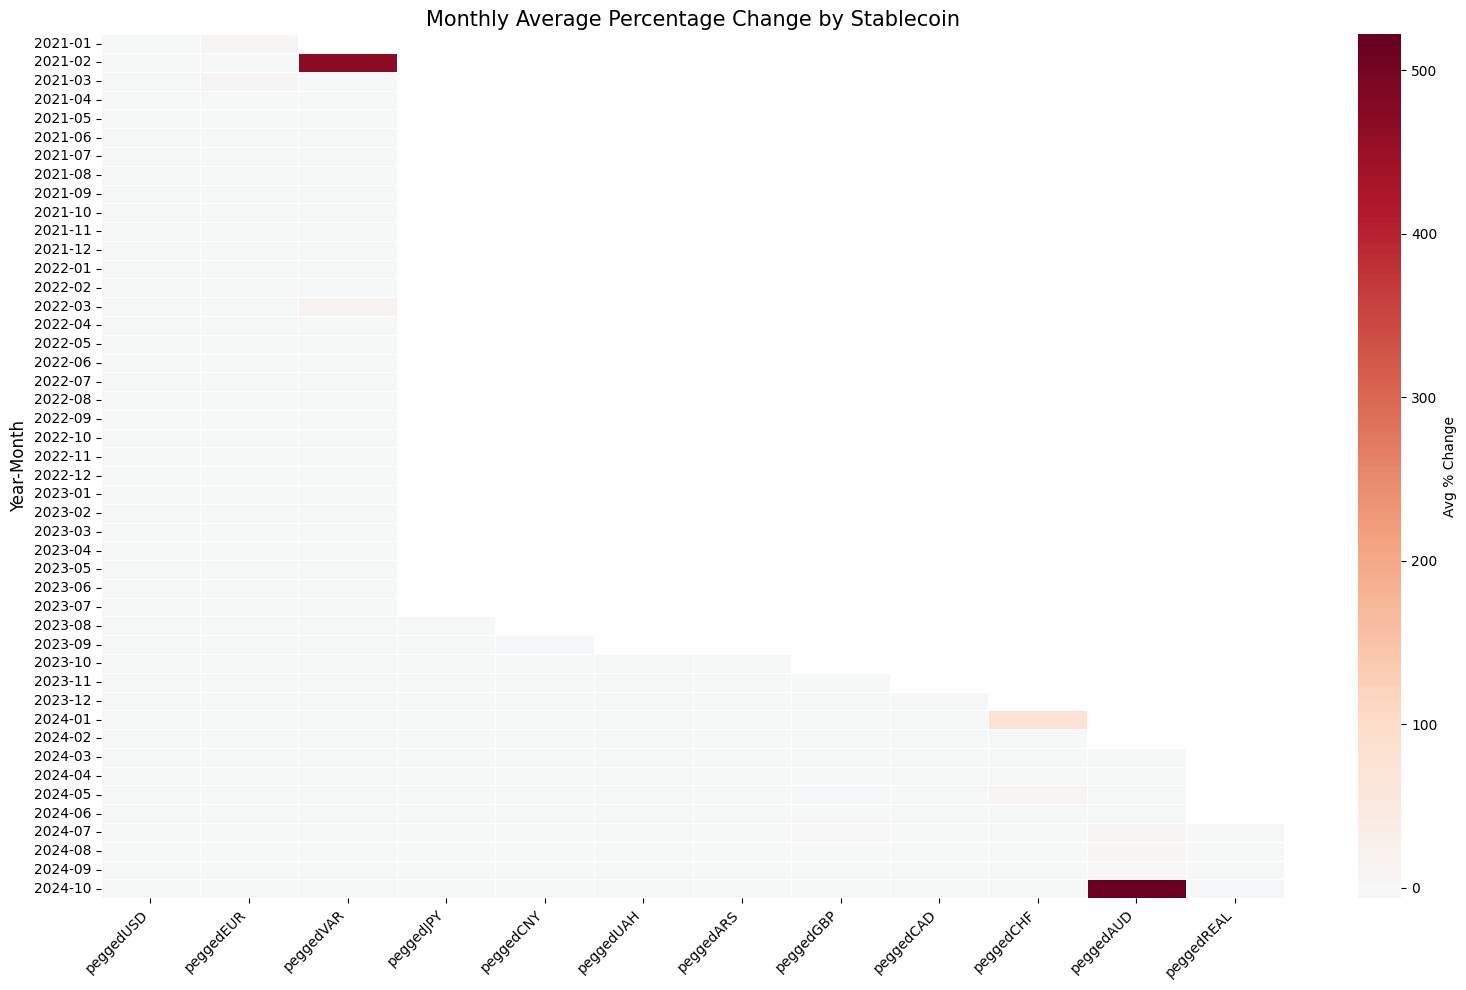

In [51]:
# Daily Percentage Change Heatmap
# Calculate daily percentage changes
pct_changes = df_indexed[coins].pct_change() * 100

# Create a DataFrame with year and month as indices for the heatmap
def get_month_year(date):
    return date.strftime('%Y-%m')

# Filter to only include columns with sufficient non-null data
active_coins = [coin for coin in coins if pct_changes[coin].count() > 30]

if active_coins:
    monthly_pct = pct_changes[active_coins].copy()
    monthly_pct['month_year'] = [get_month_year(idx) for idx in monthly_pct.index]
    
    # Group by month-year and calculate mean
    monthly_avg_change = monthly_pct.groupby('month_year')[active_coins].mean()
    
    # Convert to a pivot table for visualization
    plt.figure(figsize=(16, 10))
    sns.heatmap(monthly_avg_change, cmap='RdBu_r', center=0, 
                linewidths=0.5, cbar_kws={'label': 'Avg % Change'})
    plt.title('Monthly Average Percentage Change by Stablecoin', fontsize=15)
    plt.ylabel('Year-Month', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('monthly_pct_change_heatmap.png', dpi=300)
    plt.show()

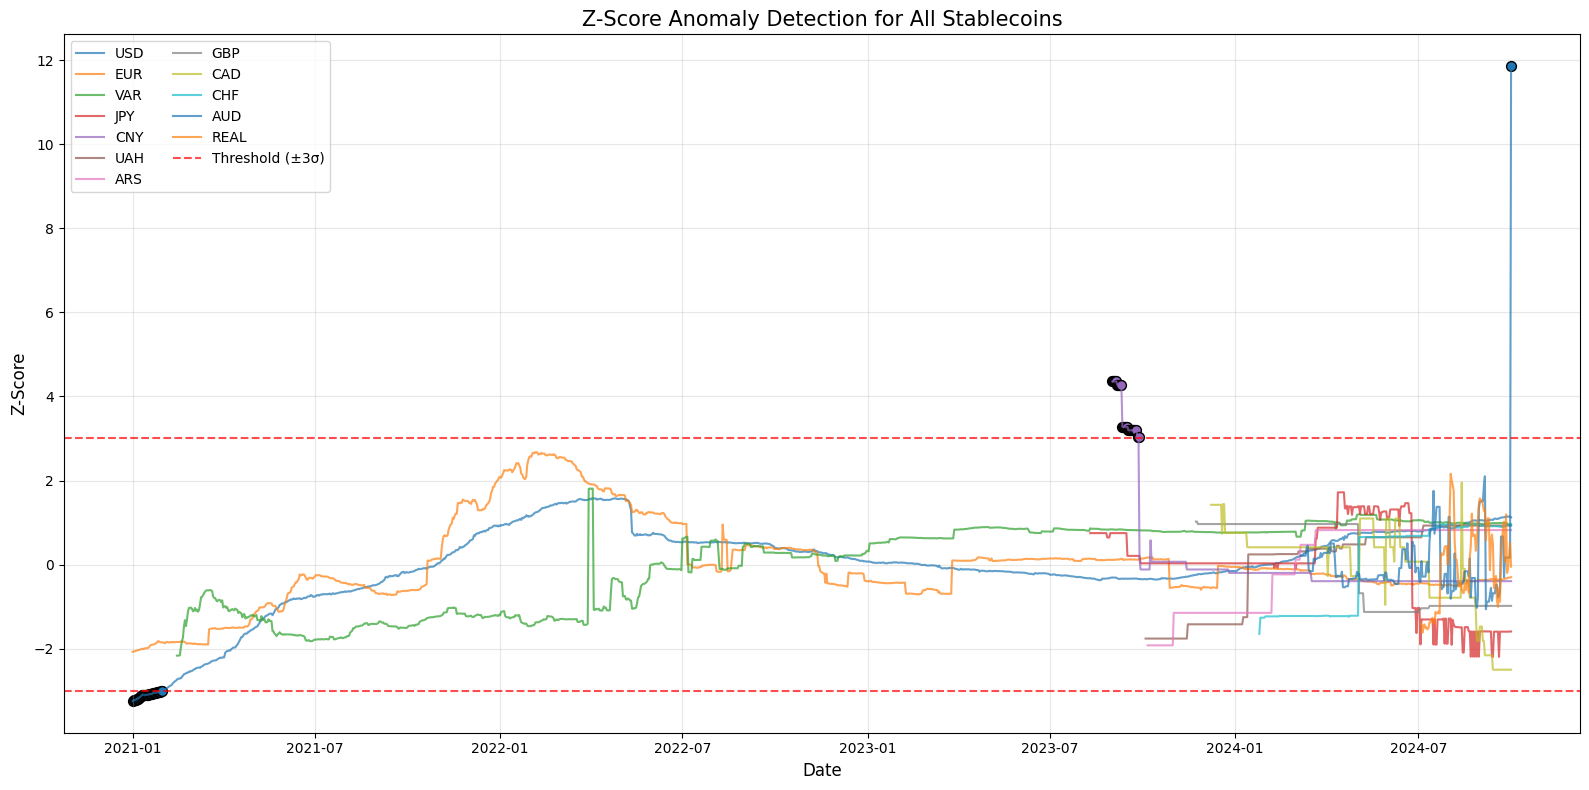

In [54]:
# Z-Score Based Anomaly Detection for All Stablecoins
plt.figure(figsize=(16, 8))

# Calculate Z-scores for each coin
z_scores = {}
anomalies_by_coin = {}

# Only analyze coins with sufficient data
for coin in coins:
    coin_data = df_indexed[coin].dropna()
    if len(coin_data) > 30:  # At least 30 data points
        # Calculate Z-score
        mean_val = coin_data.mean()
        std_val = coin_data.std()
        if std_val > 0:  # Avoid division by zero
            z_scores[coin] = (coin_data - mean_val) / std_val
            
            # Mark points beyond 3 standard deviations as anomalies
            anomalies_by_coin[coin] = coin_data[abs(z_scores[coin]) > 3]

# Prepare the plot
anomaly_count = sum(len(anoms) for anoms in anomalies_by_coin.values())

if anomaly_count > 0:
    # Set up color cycle for different coins
    colors = plt.cm.tab10.colors
    
    # Main plot
    for i, coin in enumerate(z_scores.keys()):
        color = colors[i % len(colors)]
        plt.plot(z_scores[coin].index, z_scores[coin], 
                 label=coin.replace('pegged', ''), color=color, alpha=0.7)
        
        # Plot anomalies for this coin
        if coin in anomalies_by_coin and len(anomalies_by_coin[coin]) > 0:
            anomaly_indices = anomalies_by_coin[coin].index
            plt.scatter(anomaly_indices, z_scores[coin].loc[anomaly_indices], 
                       color=color, s=50, edgecolor='black')
    
    # Add threshold lines
    plt.axhline(y=3, color='r', linestyle='--', alpha=0.7, label='Threshold (±3σ)')
    plt.axhline(y=-3, color='r', linestyle='--', alpha=0.7)
    
    plt.title('Z-Score Anomaly Detection for All Stablecoins', fontsize=15)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Z-Score', fontsize=12)
    plt.legend(loc='best', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('z_score_all_coins.png', dpi=300)
    plt.show()

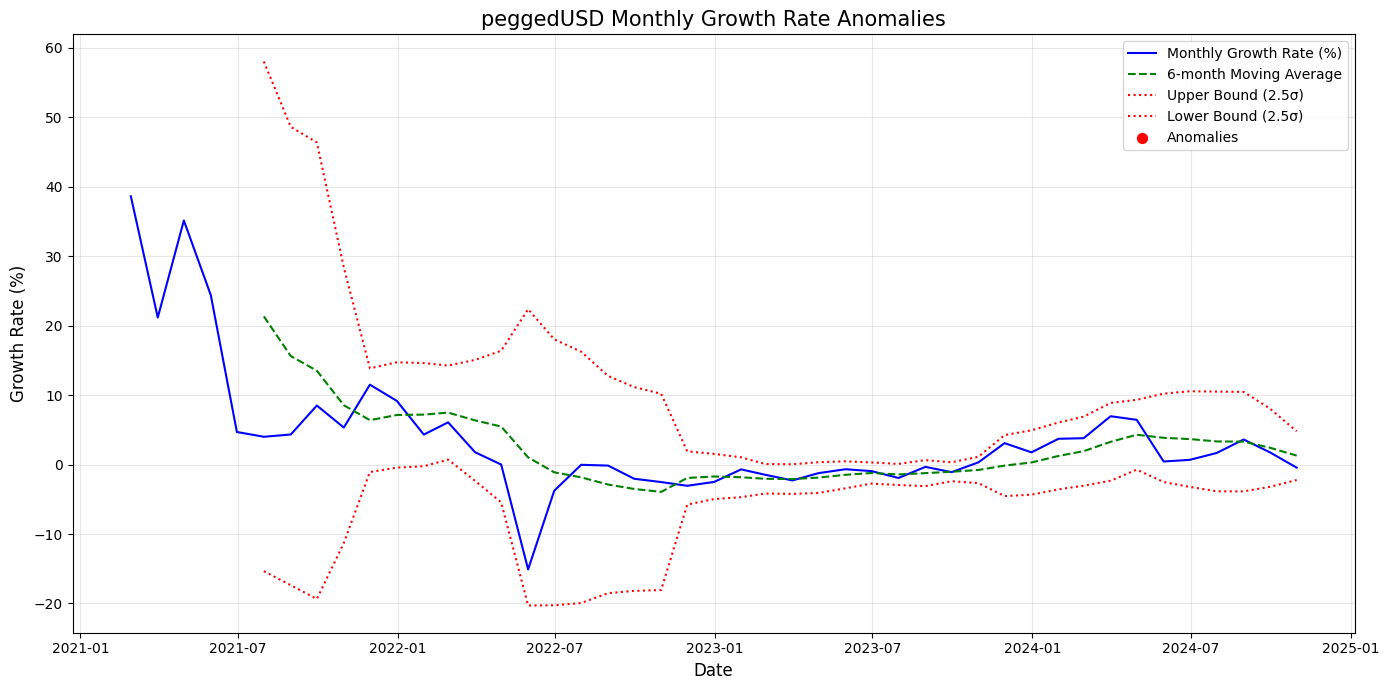

In [55]:
# Anomaly Detection in Growth Rates
plt.figure(figsize=(14, 7))

# Calculate monthly growth rates
growth_rates = monthly.pct_change() * 100

# Calculate rolling statistics for growth rates
window = 6  # 6-month window
rolling_mean_growth = growth_rates.rolling(window=window).mean()
rolling_std_growth = growth_rates.rolling(window=window).std()

# Define bounds for anomalies (2.5 standard deviations for growth rates)
upper_bound_growth = rolling_mean_growth + (2.5 * rolling_std_growth)
lower_bound_growth = rolling_mean_growth - (2.5 * rolling_std_growth)

# Identify anomalies
growth_anomalies = growth_rates[((growth_rates > upper_bound_growth) | 
                                 (growth_rates < lower_bound_growth)) &
                                 (growth_rates.notnull())]

# Plot
plt.plot(growth_rates.index, growth_rates, label='Monthly Growth Rate (%)', color='blue')
plt.plot(rolling_mean_growth.index, rolling_mean_growth, 
         label=f'{window}-month Moving Average', color='green', linestyle='--')
plt.plot(upper_bound_growth.index, upper_bound_growth, 
         label='Upper Bound (2.5σ)', color='red', linestyle=':')
plt.plot(lower_bound_growth.index, lower_bound_growth, 
         label='Lower Bound (2.5σ)', color='red', linestyle=':')

# Mark anomalies
plt.scatter(growth_anomalies.index, growth_anomalies, 
            color='red', label='Anomalies', s=50)

# Annotate significant anomalies
if len(growth_anomalies) > 0:
    # Get top 3 anomalies (by absolute value)
    top_growth_anomalies = growth_anomalies.abs().nlargest(3)
    
    for idx, value in top_growth_anomalies.items():
        plt.annotate(f"{idx.strftime('%Y-%m')}: {growth_anomalies[idx]:.1f}%", 
                    xy=(idx, growth_anomalies[idx]),
                    xytext=(10, 20),
                    textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'),
                    bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))

plt.title('peggedUSD Monthly Growth Rate Anomalies', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('growth_rate_anomalies.png', dpi=300)
plt.show()

In [57]:
from scipy import stats

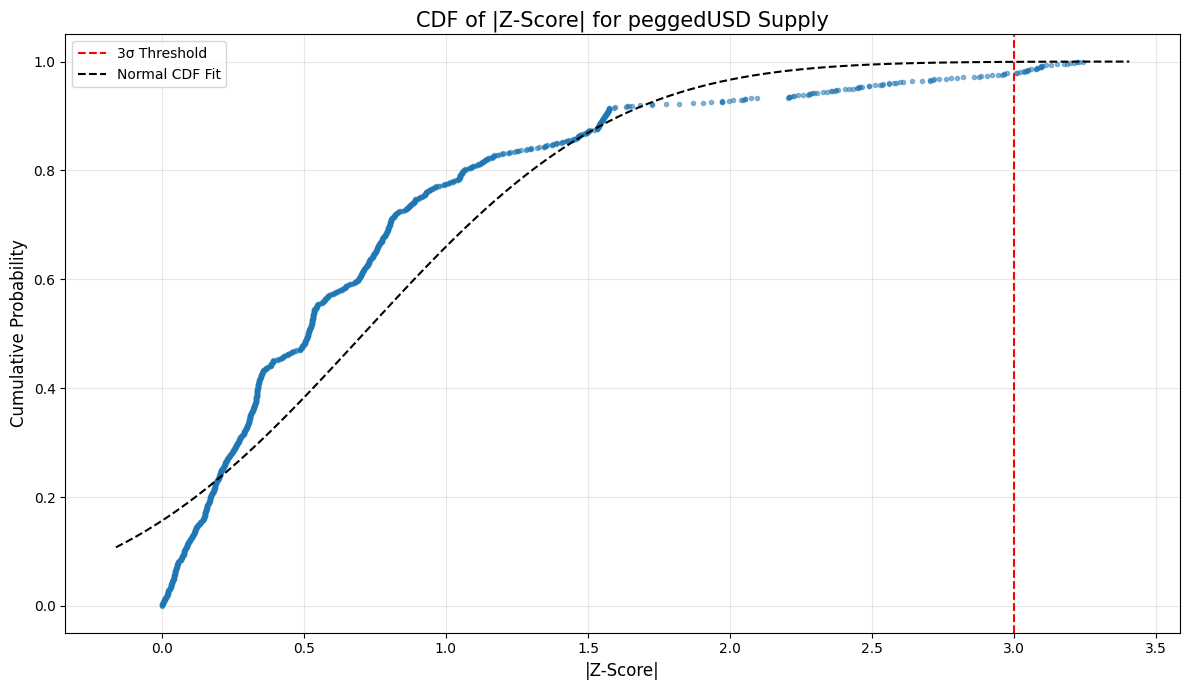

In [58]:
# Cumulative Distribution Function for Anomaly Score
plt.figure(figsize=(12, 7))

# Create an anomaly score based on z-scores for peggedUSD
usd_data = df_indexed['peggedUSD'].dropna()
if len(usd_data) > 0 and usd_data.std() > 0:  # Check for valid data
    z_usd = abs((usd_data - usd_data.mean()) / usd_data.std())

    # Sort the z-scores
    sorted_z = np.sort(z_usd.values)
    cumulative_prob = np.arange(1, len(sorted_z) + 1) / len(sorted_z)

    # Plot CDF
    plt.plot(sorted_z, cumulative_prob, marker='.', linestyle='none', alpha=0.5)
    plt.axvline(x=3, color='r', linestyle='--', label='3σ Threshold')

    # Fit a normal distribution
    fit_mean, fit_std = stats.norm.fit(z_usd)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.cdf(x, fit_mean, fit_std)
    plt.plot(x, p, 'k', linestyle='--', label='Normal CDF Fit')

    plt.title('CDF of |Z-Score| for peggedUSD Supply', fontsize=15)
    plt.xlabel('|Z-Score|', fontsize=12)
    plt.ylabel('Cumulative Probability', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('z_score_cdf.png', dpi=300)
    plt.show()

# VISUALISASI

<Figure size 640x480 with 0 Axes>

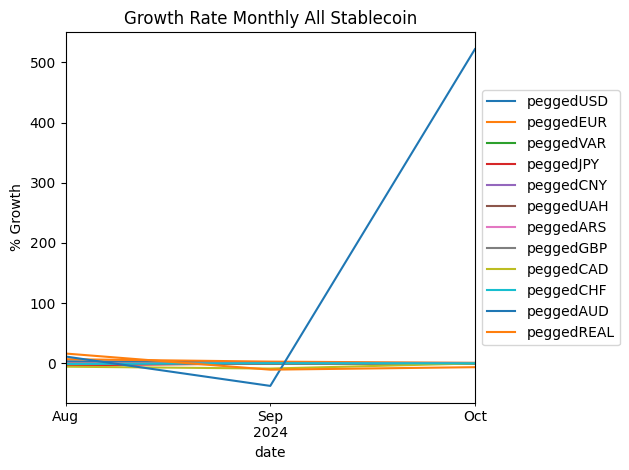

In [59]:
# Growth Rate All Stablecoin
growth_all = monthly_all.pct_change() * 100

plt.figure()
growth_all.dropna().plot()
plt.ylabel('% Growth')
plt.title('Growth Rate Monthly All Stablecoin')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

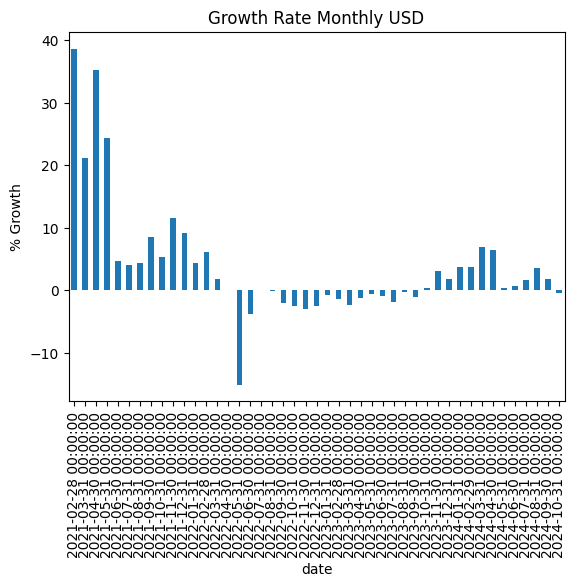

In [60]:
# Growth rate monthly
growth = monthly.pct_change().dropna() * 100
growth.plot.bar()
plt.ylabel('% Growth')
plt.title('Growth Rate Monthly USD')
plt.show()


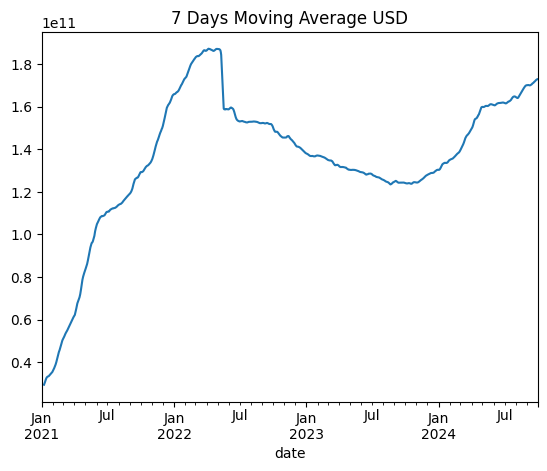

In [61]:
# 7 Days MA
df.set_index('date')['peggedUSD'].rolling(7).mean().plot()
plt.title('7 Days Moving Average USD')
plt.show()


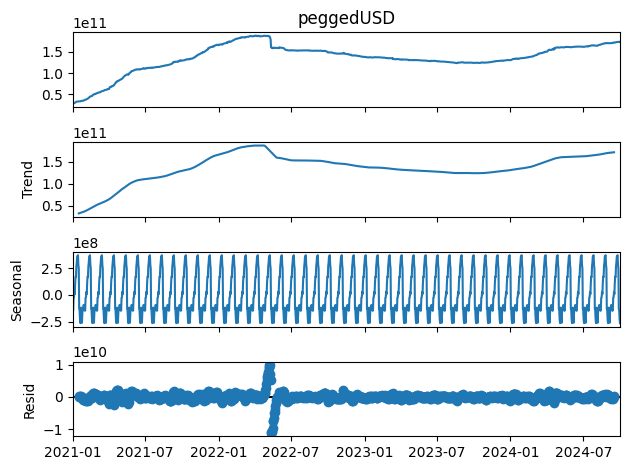

In [62]:
# Seasonal Decomposition USD
series = df.set_index('date')['peggedUSD'].dropna()
res = seasonal_decompose(series, model='additive', period=30)
res.plot()
plt.show()

# Forecasting

22:26:51 - cmdstanpy - INFO - Chain [1] start processing
22:26:51 - cmdstanpy - INFO - Chain [1] done processing


Text(0.5, 0.98, '30-Day Forecast of USD-Pegged Stablecoin Supply')

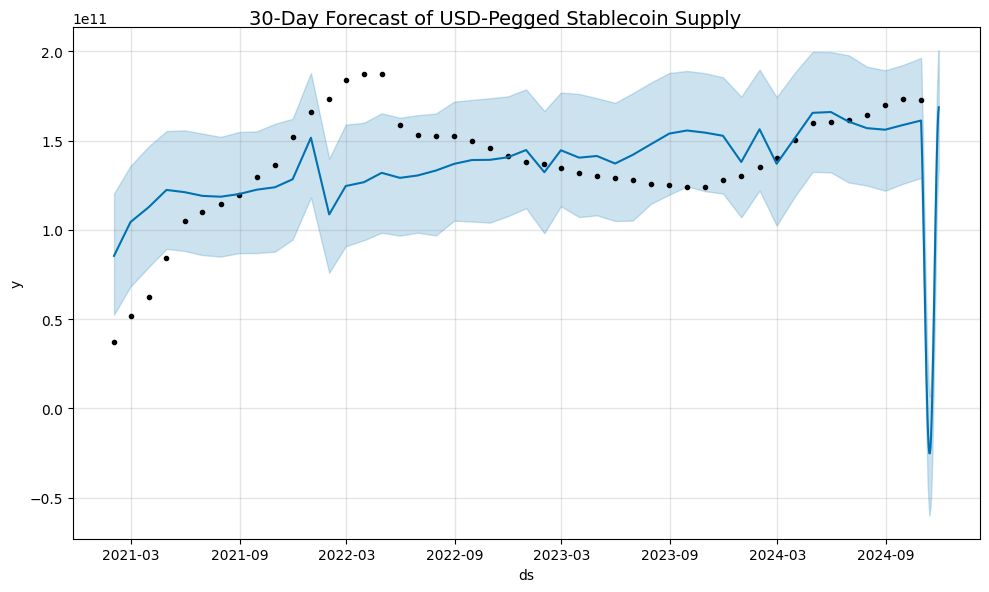

In [63]:
# 30 Days forecast
df_prophet = monthly.reset_index().rename(columns={'date':'ds','peggedUSD':'y'})
m = Prophet(); m.fit(df_prophet)
future = m.make_future_dataframe(periods=30, freq='D')
fc = m.predict(future)
fig = m.plot(fc)
fig.suptitle('30-Day Forecast of USD-Pegged Stablecoin Supply', fontsize=14)


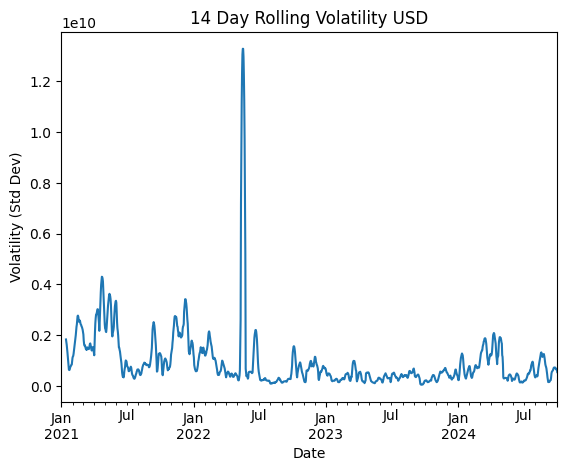

In [64]:
# 14 Day Rolling Volatility
vol = df.set_index('date')['peggedUSD'].rolling(14).std()

plt.figure()
vol.plot()
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev)')
plt.title('14 Day Rolling Volatility USD')
plt.show()

Evaluation on Test Set (last 12 months):
MAPE: 18.95%
RMSE: 34,558,035,172


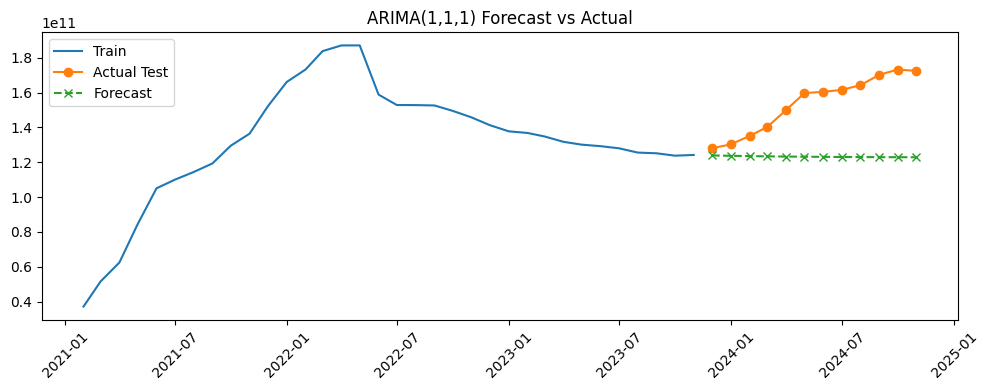

In [65]:
# Split for ARIMA
train = monthly[:-12]
test = monthly[-12:]

# Fit ARIMA(1,1,1)
model = ARIMA(train, order=(1,1,1)).fit()

# Forecast for test period
pred = model.forecast(steps=12)

# Calculate error metrics
mape = mean_absolute_percentage_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print(f"Evaluation on Test Set (last 12 months):")
print(f"MAPE: {mape*100:.2f}%")
print(f"RMSE: {rmse:,.0f}")

# Plot Test vs Forecast
plt.figure(figsize=(10, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, 'o-', label='Actual Test')
plt.plot(pred.index, pred, 'x--', label='Forecast')
plt.title('ARIMA(1,1,1) Forecast vs Actual')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


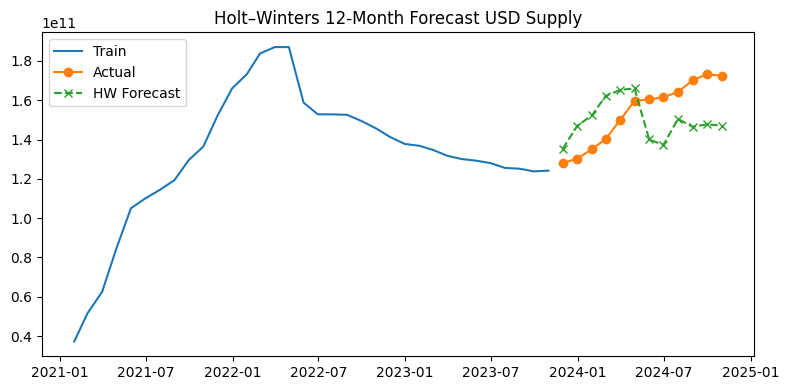

In [66]:
# Fit Holt-Winters (additive trend & seasonal)
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# Forecast 12 bulan ke depan
hw_forecast = hw_model.forecast(12)

# Plot hasil
plt.figure(figsize=(8,4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, 'o-', label='Actual')
plt.plot(hw_forecast.index, hw_forecast, 'x--', label='HW Forecast')
plt.title('Holt–Winters 12-Month Forecast USD Supply')
plt.legend()
plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few obs

Best SARIMAX params: order=(0, 0, 0), seasonal_order=(2, 2, 2, 12), AIC=10.0
MAPE: 35.53%
RMSE: 61,070,460,905


/opt/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


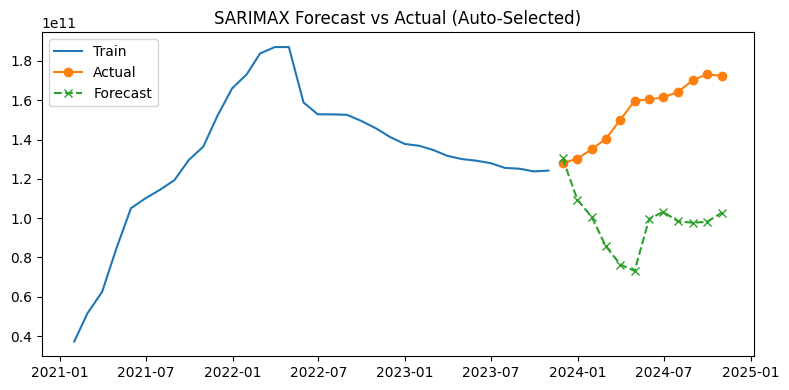

In [67]:
# Grid search for best SARIMAX(p,d,q)(P,D,Q,12) by AIC
p = d = q = range(0, 3)
pdq = [(x[0], x[1], x[2]) for x in zip(p, d, q)]
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in zip(p, d, q)]

best_aic = float('inf')
best_params = None
best_model = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            mod = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                          enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_params = (order, seasonal_order)
                best_model = res
        except Exception:
            continue

print(f"Best SARIMAX params: order={best_params[0]}, seasonal_order={best_params[1]}, AIC={best_aic:.1f}")

# Forecast with best model
forecast = best_model.get_forecast(steps=12)
pred = forecast.predicted_mean

# Compute error metrics
mape = mean_absolute_percentage_error(test, pred)
mse  = mean_squared_error(test, pred)
rmse = np.sqrt(mse)
print(f"MAPE: {mape*100:.2f}%")
print(f"RMSE: {rmse:,.0f}")

# Plot actual vs forecast
plt.figure(figsize=(8, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, 'o-', label='Actual')
plt.plot(pred.index, pred, 'x--', label='Forecast')
plt.title('SARIMAX Forecast vs Actual (Auto-Selected)')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_62763/585744244.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M').last().dropna()
22:26:53 - cmdstanpy - INFO - Chain [1] start processing
22:26:53 - cmdstanpy - INFO - Chain [1] done processing
/opt/miniconda3/lib/python3.12/site-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


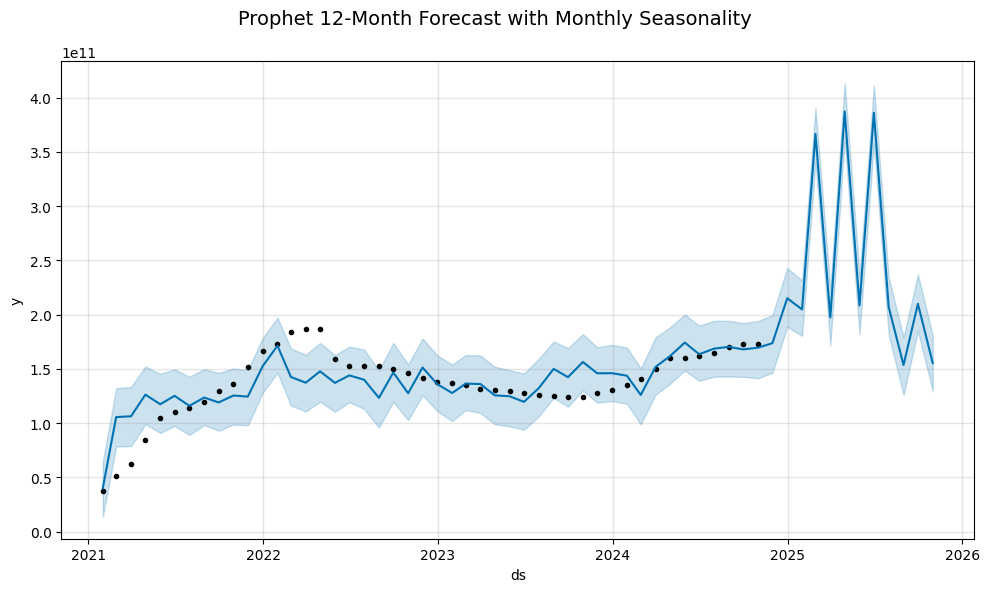

In [68]:
df_prophet = (
    df.set_index('date')['peggedUSD']
      .resample('M').last().dropna()
      .reset_index()
      .rename(columns={'date':'ds','peggedUSD':'y'})
)

m = Prophet(
    yearly_seasonality=True,      # tangkap pola tahunan
    weekly_seasonality=False,
    daily_seasonality=False
)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
m.fit(df_prophet)

future = m.make_future_dataframe(periods=12, freq='M')
fc     = m.predict(future)

fig = m.plot(fc)
fig.suptitle('Prophet 12-Month Forecast with Monthly Seasonality', fontsize=14)
plt.tight_layout()
plt.show()
